In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ruthgn/bank-marketing-data-set/bank-direct-marketing-campaigns.csv


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ruthgn/bank-marketing-data-set/bank-direct-marketing-campaigns.csv


In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ruthgn/bank-marketing-data-set/bank-direct-marketing-campaigns.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv('/kaggle/input/datasets/ruthgn/bank-marketing-data-set/bank-direct-marketing-campaigns.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.shape
df.info()
df.describe(include='all').T
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [6]:
for col in df.select_dtypes(include='object').columns:
    print(col, '->', df[col].unique())

job -> ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital -> ['married' 'single' 'divorced' 'unknown']
education -> ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default -> ['no' 'unknown' 'yes']
housing -> ['no' 'yes' 'unknown']
loan -> ['no' 'yes' 'unknown']
contact -> ['telephone' 'cellular']
month -> ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week -> ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome -> ['nonexistent' 'failure' 'success']
y -> ['no' 'yes']


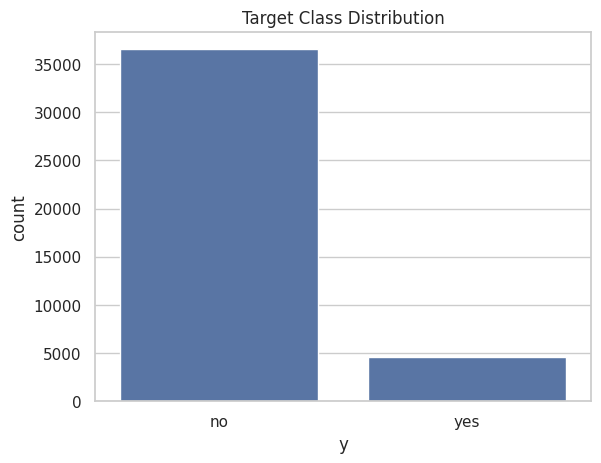

In [7]:
df['y'].value_counts(normalize=True) * 100

sns.countplot(x='y', data=df)
plt.title('Target Class Distribution')
plt.show()

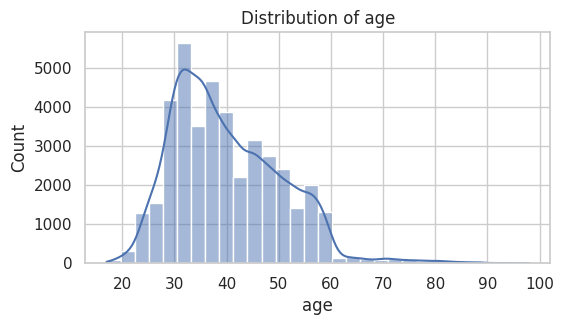

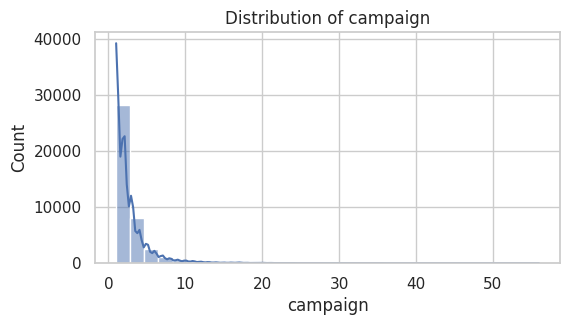

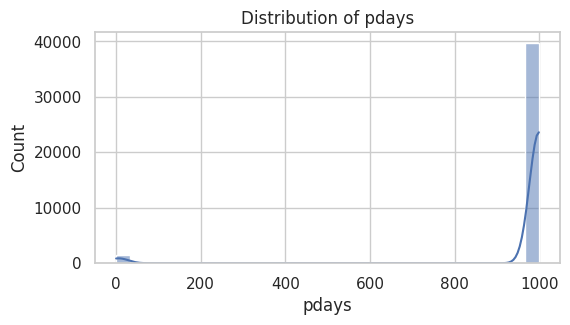

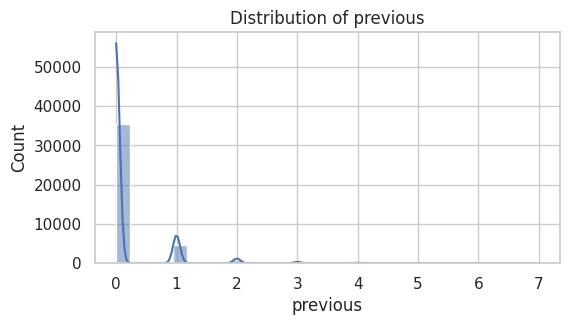

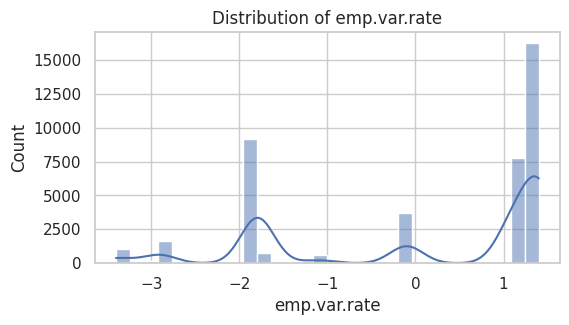

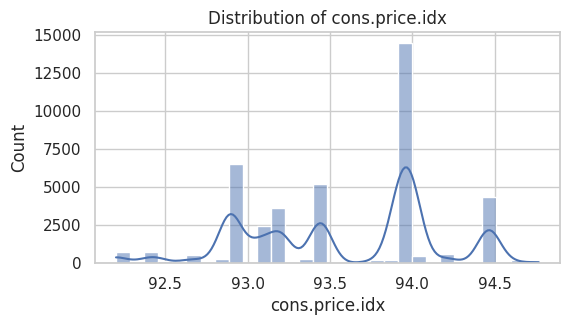

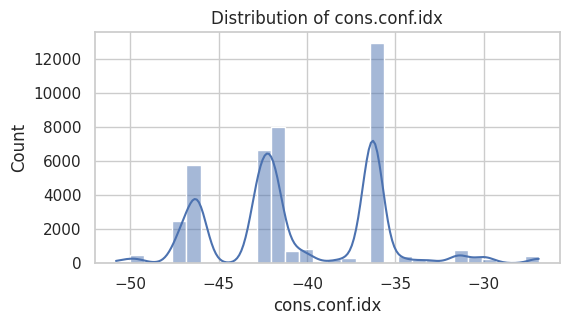

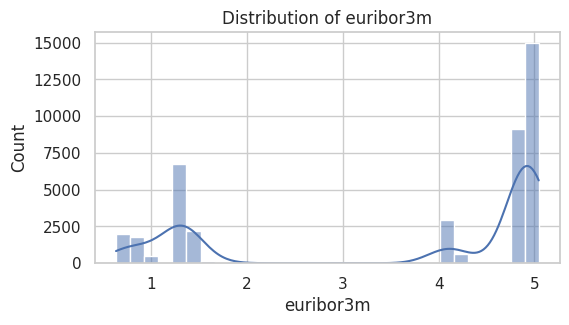

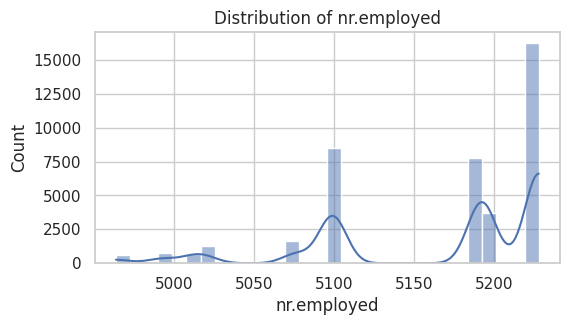

In [8]:
numeric_cols = ['age', 'campaign', 'pdays', 'previous',
                 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

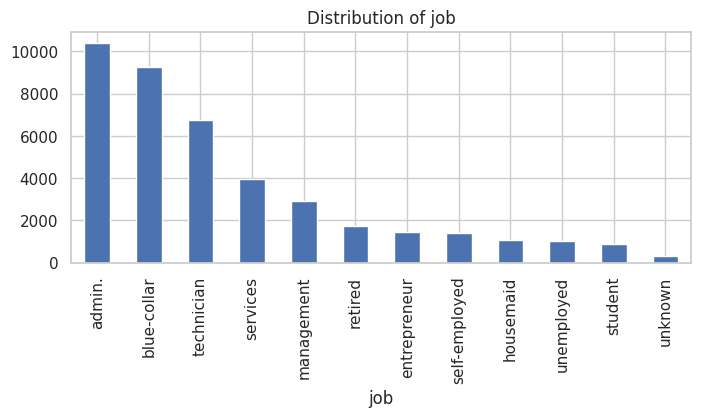

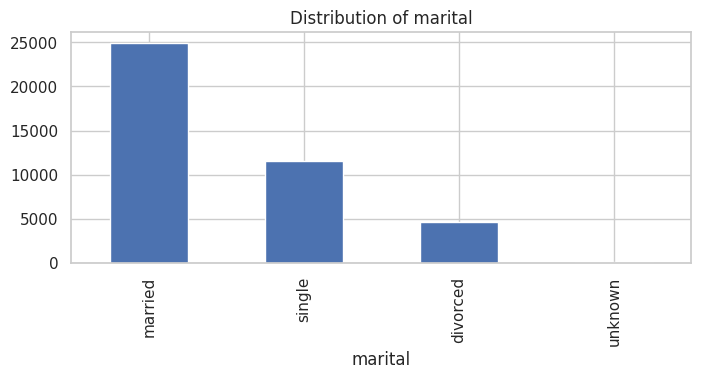

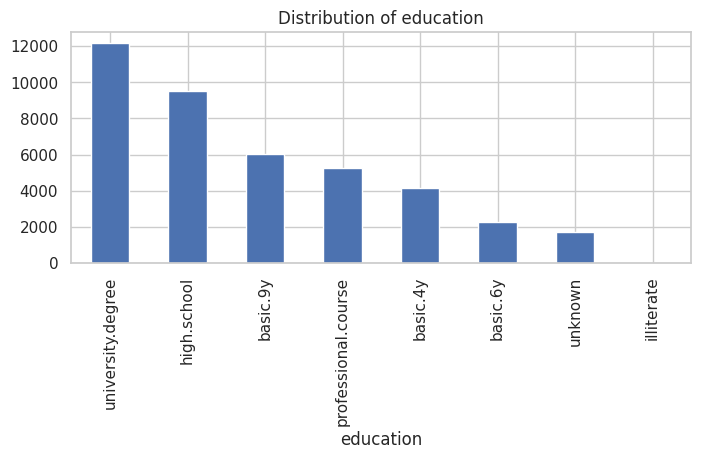

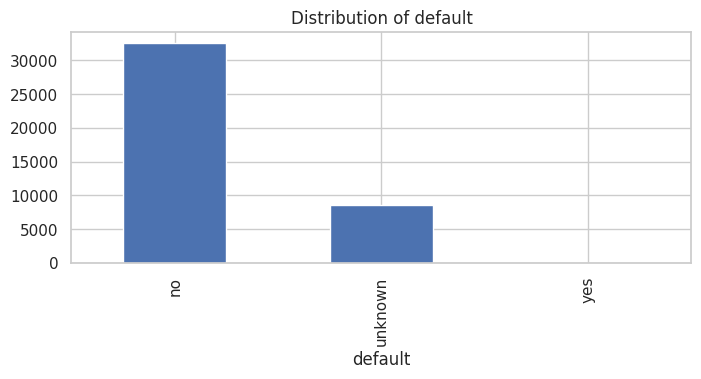

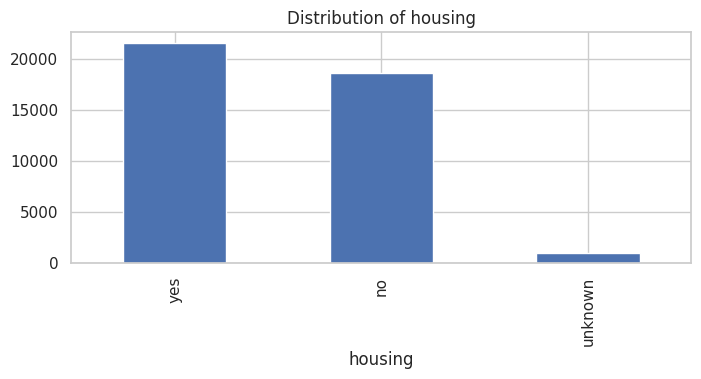

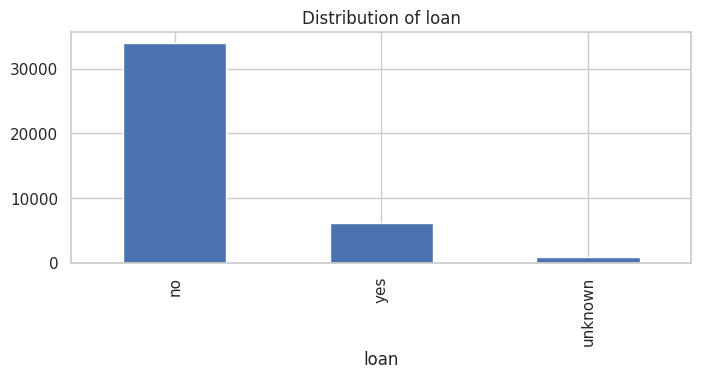

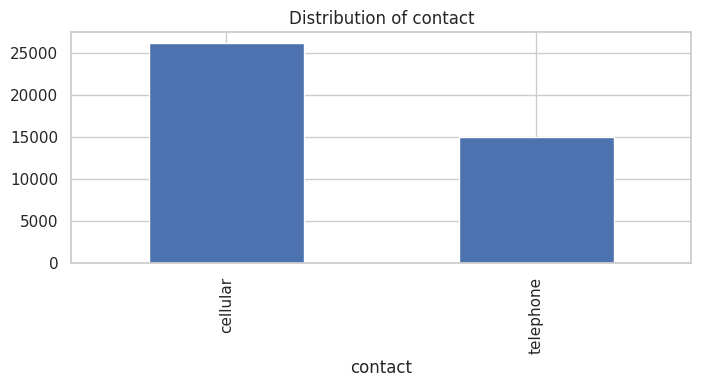

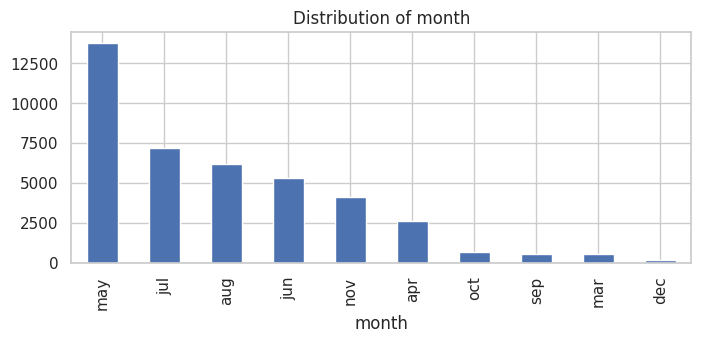

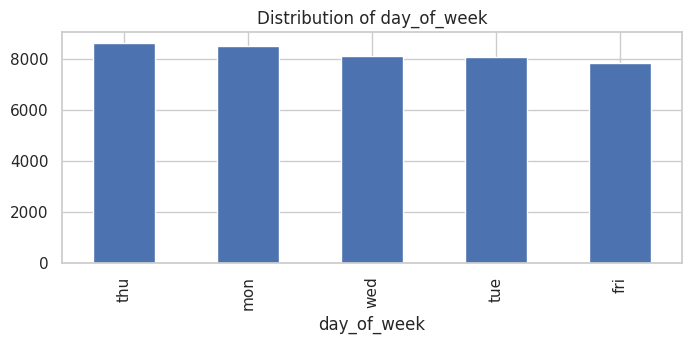

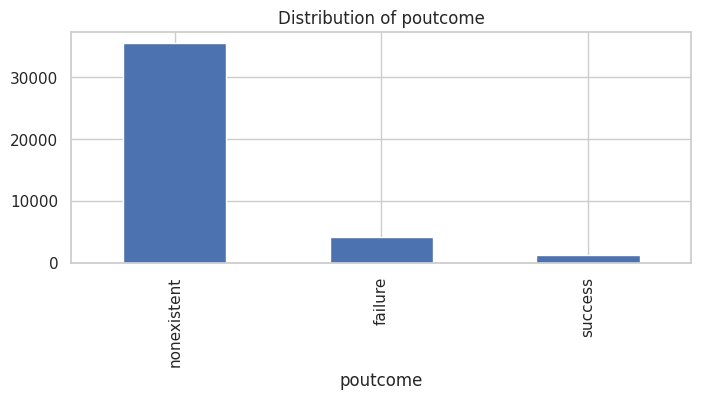

In [9]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

for col in cat_cols:
    plt.figure(figsize=(8,3))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.show()

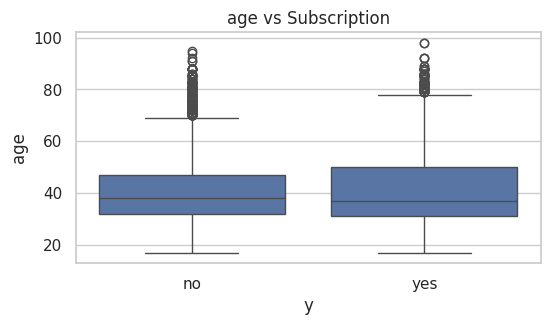

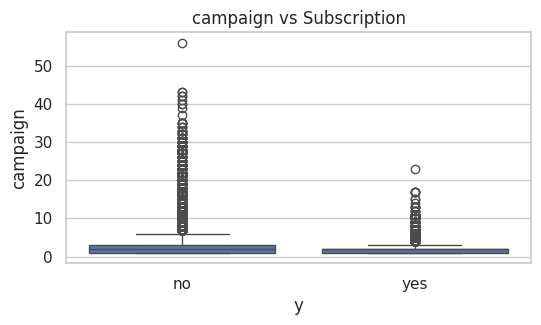

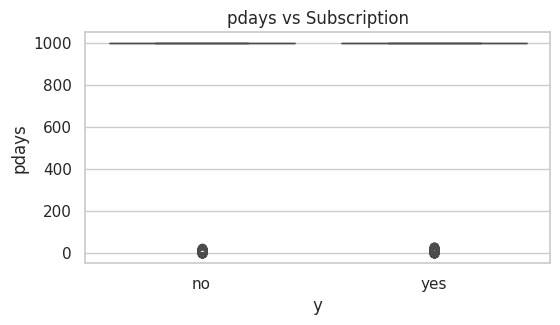

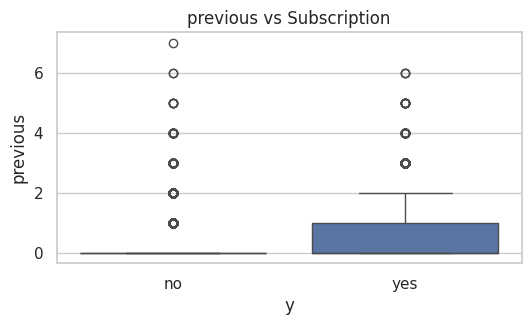

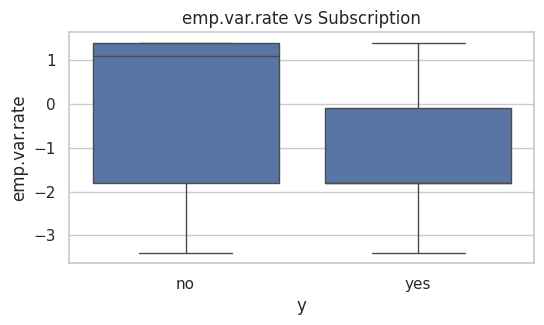

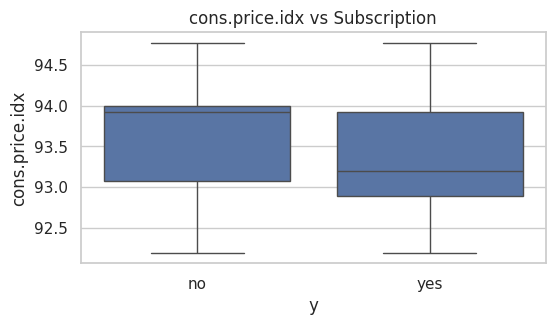

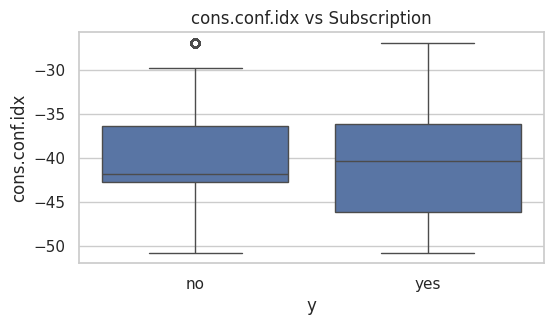

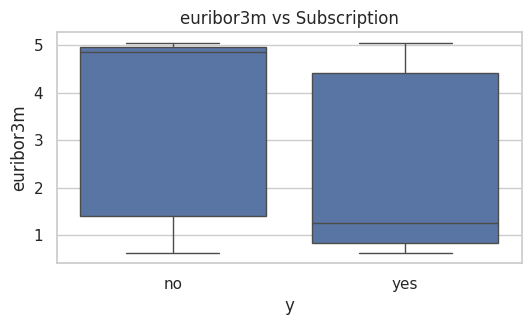

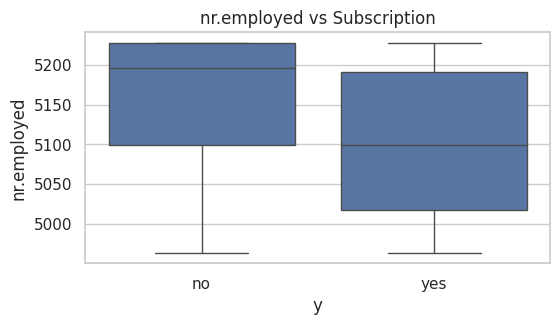

In [10]:
# Numeric vs target
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'{col} vs Subscription')
    plt.show()

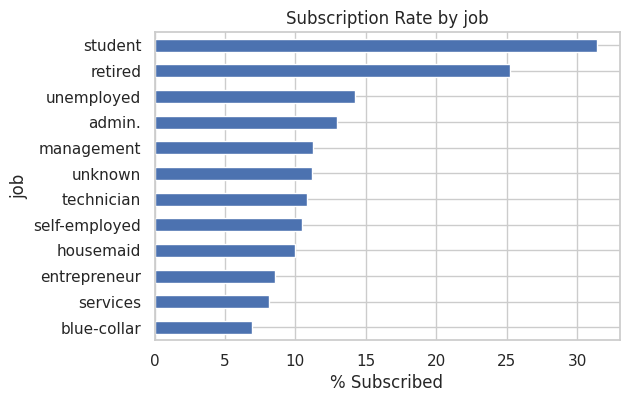

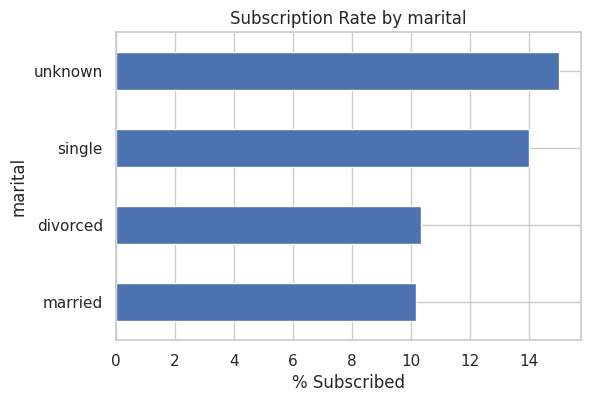

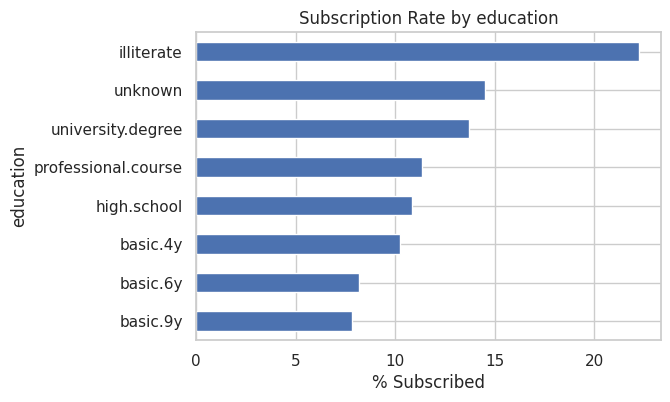

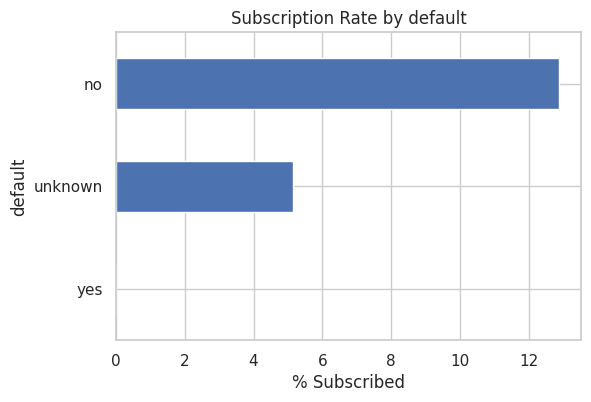

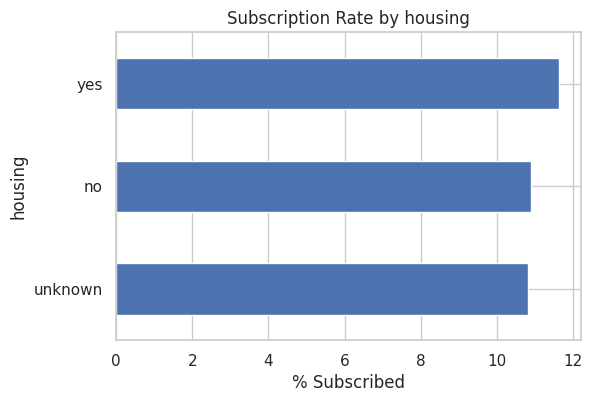

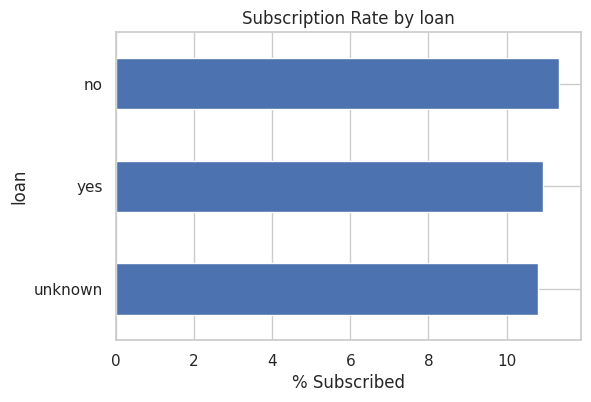

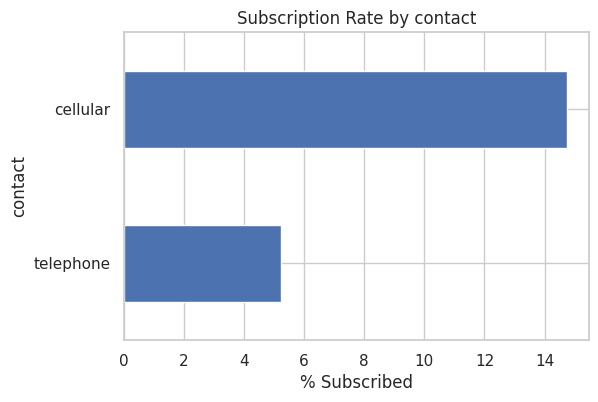

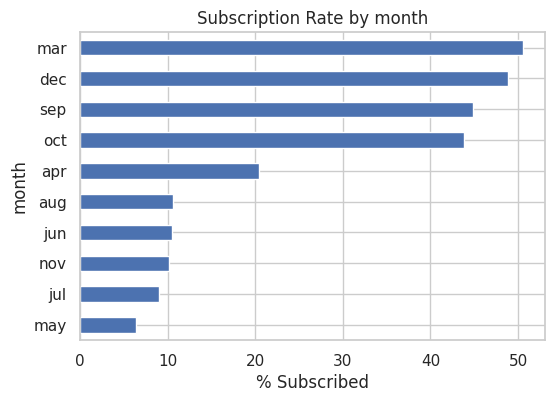

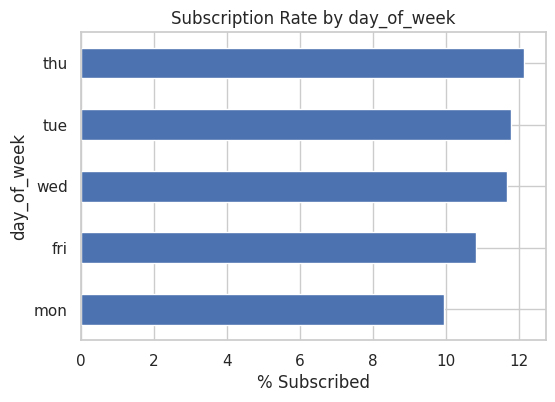

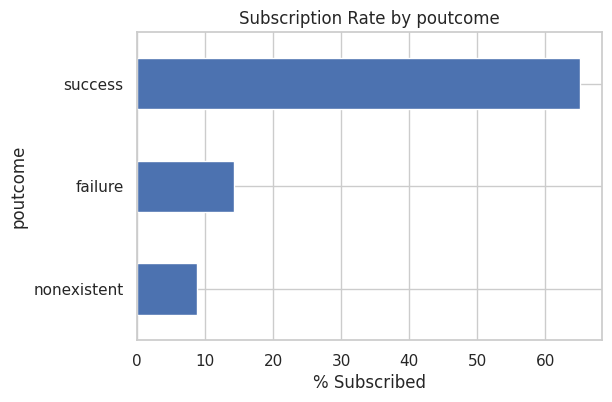

In [11]:
# Categorical vs target (subscription rate by category)
for col in cat_cols:
    rate = df.groupby(col)['y'].apply(lambda x: (x=='yes').mean()*100)
    rate.sort_values().plot(kind='barh', figsize=(6,4))
    plt.title(f'Subscription Rate by {col}')
    plt.xlabel('% Subscribed')
    plt.show()

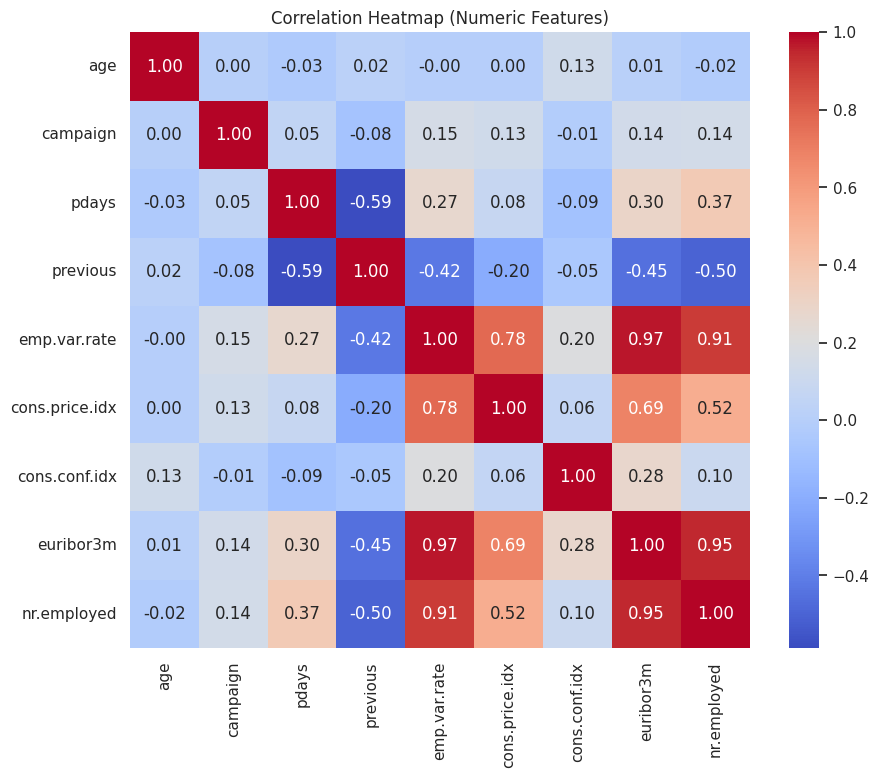

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

In [13]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    contingency = pd.crosstab(df[col], df['y'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f'{col}: p-value = {p:.5f}')

job: p-value = 0.00000
marital: p-value = 0.00000
education: p-value = 0.00000
default: p-value = 0.00000
housing: p-value = 0.05829
loan: p-value = 0.57868
contact: p-value = 0.00000
month: p-value = 0.00000
day_of_week: p-value = 0.00003
poutcome: p-value = 0.00000


In [14]:
# Age groups
df['age_group'] = pd.cut(df['age'], bins=[17,25,35,45,55,65,100],
                          labels=['18-25','26-35','36-45','46-55','56-65','65+'])

# Was previously contacted
df['was_contacted_before'] = df['pdays'].apply(lambda x: 0 if x == 999 else 1)

# Encode target
df['y_binary'] = df['y'].map({'no':0, 'yes':1})

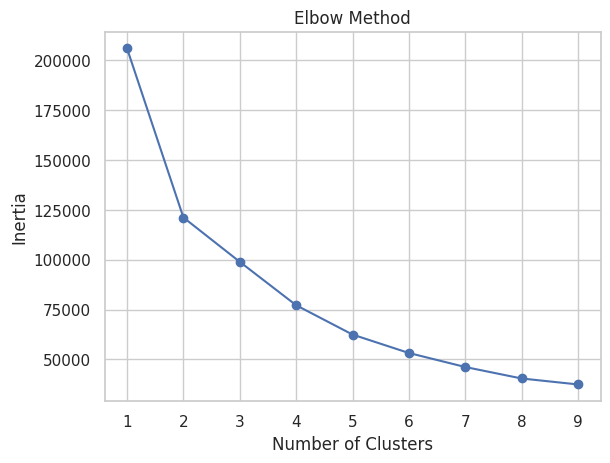

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Select features for segmentation
seg_features = df[['age', 'campaign', 'previous', 'emp.var.rate', 'euribor3m']]

scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_features)

# Elbow method to choose k
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(seg_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

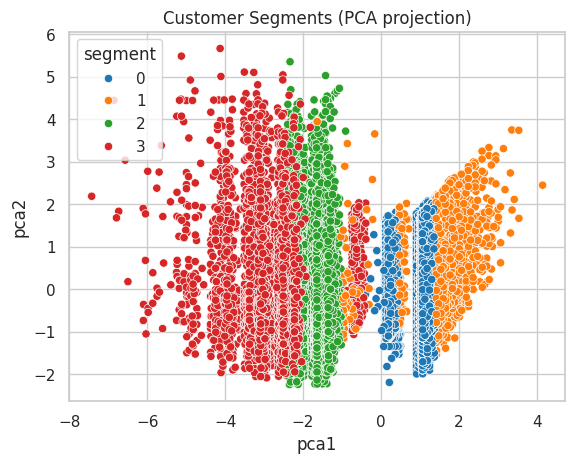

In [16]:
# Fit final model (pick k from elbow plot, e.g. k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(seg_scaled)

# Visualize with PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(seg_scaled)
df['pca1'], df['pca2'] = pca_result[:,0], pca_result[:,1]

sns.scatterplot(x='pca1', y='pca2', hue='segment', data=df, palette='tab10')
plt.title('Customer Segments (PCA projection)')
plt.show()

The clustering split customers into four groups, and the differences between them are sharp enough to act on.

Segment 3 stands out as the best use of campaign effort. These are customers who had been contacted in a past campaign, and they converted at 26.7% — the highest of any segment — while needing fewer average contacts (1.9) than the least effective group. In plain terms: reaching back out to someone the bank has already spoken to works better, and takes less work, than cold outreach.

Segment 1 is the opposite story. This group received over five times more contact attempts (11.5 on average) than any other segment, yet converted at the lowest rate of all (3.9%). This isn't a coincidence — it's a textbook diminishing-returns pattern. Past a certain number of calls, customers who haven't responded aren't becoming more likely to say yes; if anything, the repeated contact seems to be working against conversion

Segments 0 and 2 are the most interesting comparison. Both received almost identical, light contact effort (around 2 calls on average), but segment 2 converted at 21.3% while segment 0 converted at just 4.95%. Since contact volume doesn't explain this gap, something else does — likely differences in job type, education, or the timing of outreach. This is worth a follow-up cut of the data before finalizing a targeting strategy, since it points to a lower-effort, high-yield audience that isn't yet fully defined.

> What this means for campaign strategy:


Re-engaging previously contacted customers should be a standing part of future campaigns — it's the single most efficient segment identified.
There's a practical ceiling on cold outreach. Contact caps (e.g., stopping after 4-5 attempts with no response) would likely reduce wasted effort without losing much conversion.
The gap between segments 0 and 2 suggests the bank isn't yet targeting cold leads as precisely as it could. Profiling segment 2 further (job, education, month contacted) could turn this into a repeatable playbook for cold-lead selection rather than a one-off finding.


Taken together, the segmentation suggests the bank's current campaign spends effort fairly evenly across very different types of leads, when a more selective approach — leaning into warm leads, capping cold outreach, and refining who counts as a "good" cold lead — would likely convert more customers for less effort.

In [17]:
df.groupby('segment')[['age','campaign','previous']].mean()

,age,campaign,previous
segment,,,
0,40.145012,2.118530,0.000120
1,40.449116,11.482561,0.004300
2,39.289369,2.105023,0.000000
3,40.448958,1.942633,1.267059


In [18]:
df.groupby('segment')['y_binary'].mean() * 100

segment
0     4.951449
1     3.917821
2    21.331776
3    26.688046
Name: y_binary, dtype: float64